In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

# Load cleaned WASH data (from WASH_datacleaning.py output)
df = pd.read_csv('../outputs/wash_clean_data.csv')

# Also load the full time-series sheets for trend charts
FILE = '../data/JMP-WASH-in-schools-2024-data-by-country.xlsx'

In [2]:
water = pd.read_excel(FILE, sheet_name='Water Data')
sanitation = pd.read_excel(FILE, sheet_name='Sanitation Data')
hygiene = pd.read_excel(FILE, sheet_name='Hygiene Data')

for sheet in [water, sanitation, hygiene]:
    sheet['iso3'] = sheet['iso3'].astype(str)

# Use region from cleaned data for consistency
region_map = df[['ISO', 'sdg_region']].rename(columns={'ISO': 'iso3', 'sdg_region': 'region_sdg'})

water = water.merge(region_map, on='iso3', how='left')
sanitation = sanitation.merge(region_map, on='iso3', how='left')
hygiene = hygiene.merge(region_map, on='iso3', how='left')

latest_year = water['year'].max()
print(f"Cleaned data: {len(df)} countries")
print(f"Time-series data: {water['year'].min()}-{latest_year}")
print(f"Countries with all 3 basic indicators: {df[['wat_bas_nat','san_bas_nat','hyg_bas_nat']].notna().all(axis=1).sum()}")

Cleaned data: 191 countries
Time-series data: 2000-2023
Countries with all 3 basic indicators: 112


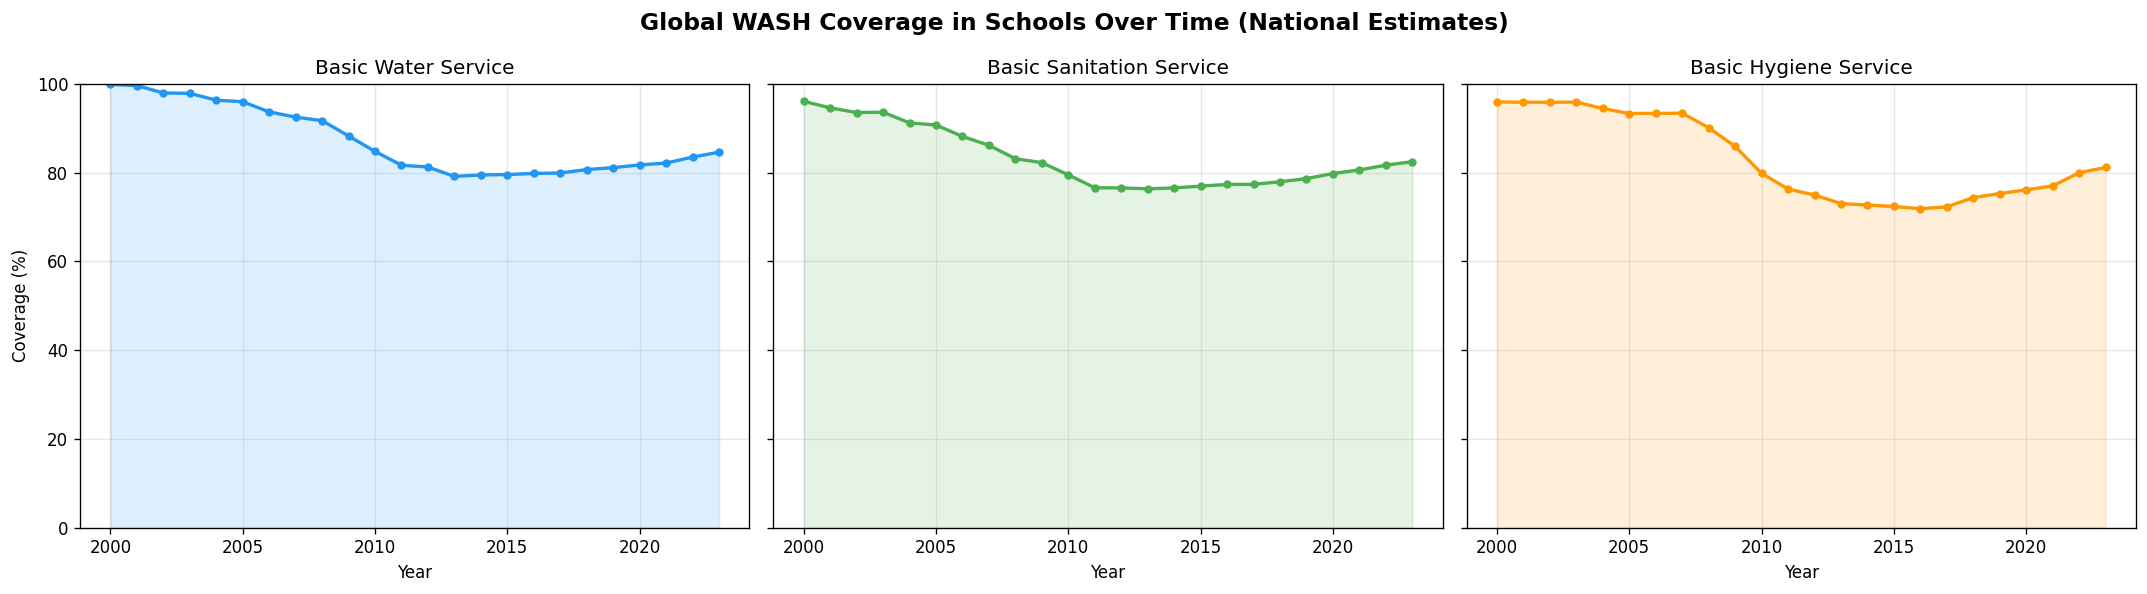

In [3]:
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig1.suptitle('Global WASH Coverage in Schools Over Time (National Estimates)', fontsize=14, fontweight='bold')

water_trend = water.groupby('year')['wat_bas_nat'].mean().dropna()
axes1[0].plot(water_trend.index, water_trend.values, color='#2196F3', linewidth=2, marker='o', markersize=4)
axes1[0].fill_between(water_trend.index, water_trend.values, alpha=0.15, color='#2196F3')
axes1[0].set_title('Basic Water Service')
axes1[0].set_xlabel('Year')
axes1[0].set_ylabel('Coverage (%)')
axes1[0].set_ylim(0, 100)
axes1[0].grid(alpha=0.3)

san_trend = sanitation.groupby('year')['san_bas_nat'].mean().dropna()
axes1[1].plot(san_trend.index, san_trend.values, color='#4CAF50', linewidth=2, marker='o', markersize=4)
axes1[1].fill_between(san_trend.index, san_trend.values, alpha=0.15, color='#4CAF50')
axes1[1].set_title('Basic Sanitation Service')
axes1[1].set_xlabel('Year')
axes1[1].grid(alpha=0.3)

hyg_trend = hygiene.groupby('year')['hyg_bas_nat'].mean().dropna()
axes1[2].plot(hyg_trend.index, hyg_trend.values, color='#FF9800', linewidth=2, marker='o', markersize=4)
axes1[2].fill_between(hyg_trend.index, hyg_trend.values, alpha=0.15, color='#FF9800')
axes1[2].set_title('Basic Hygiene Service')
axes1[2].set_xlabel('Year')
axes1[2].grid(alpha=0.3)

fig1.tight_layout()
plt.show()

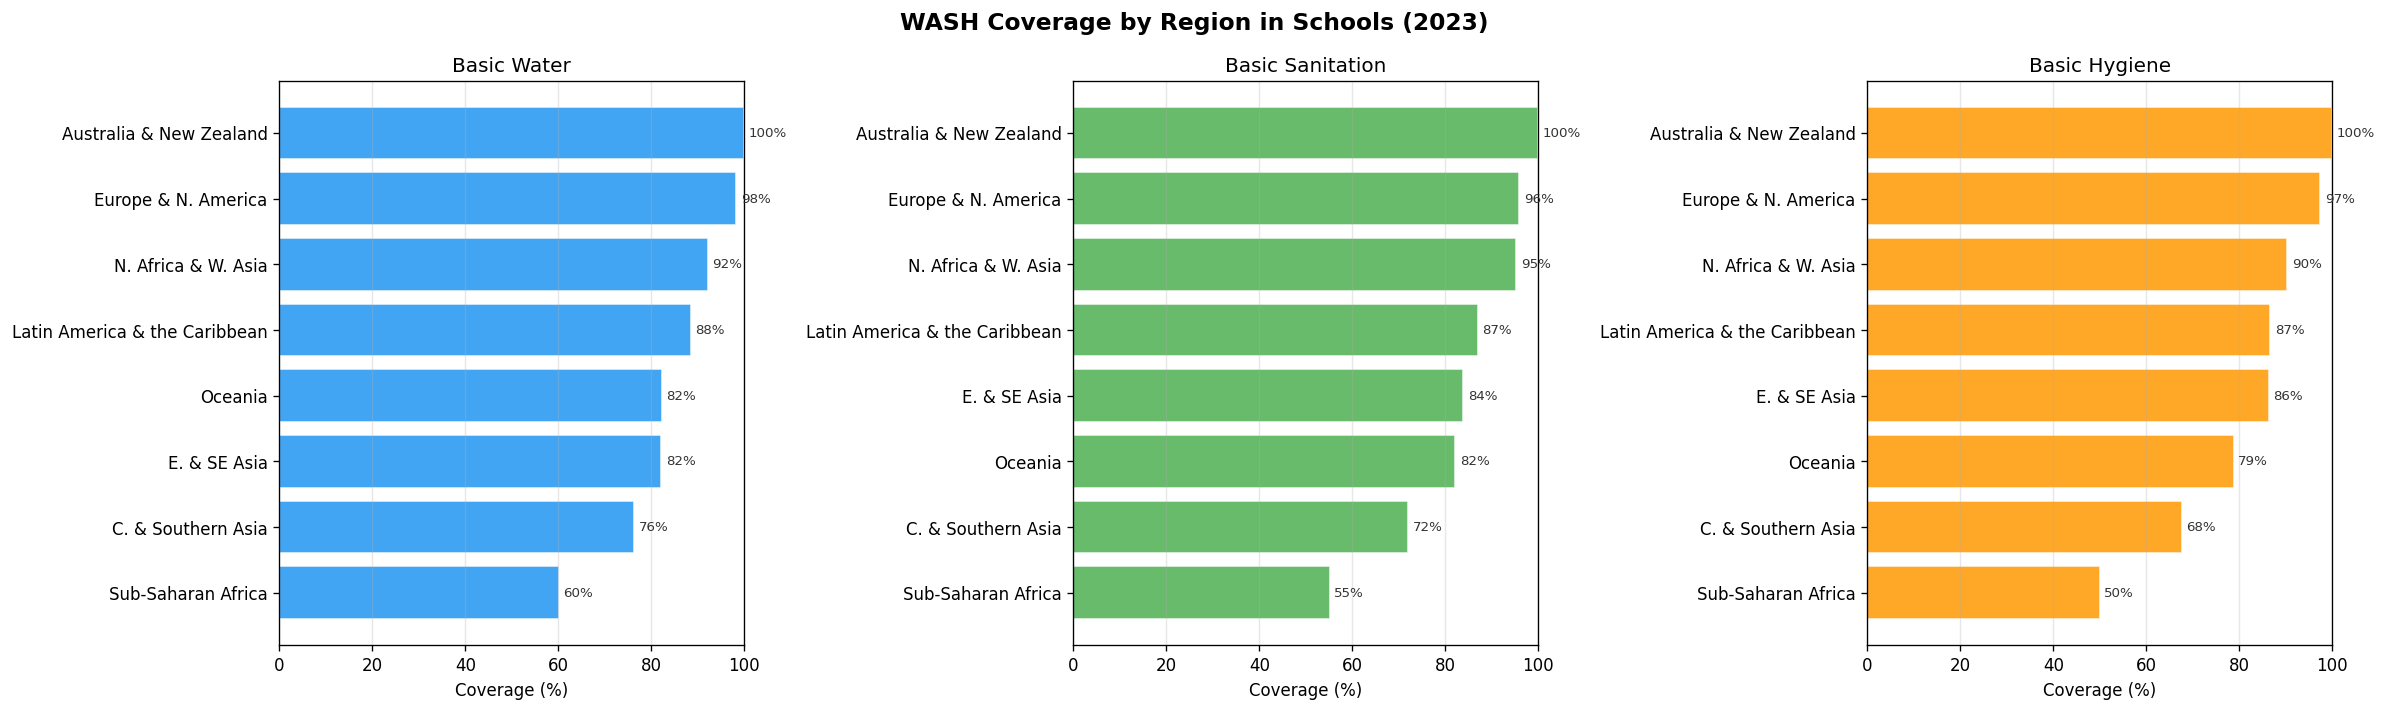

In [4]:
latest_year = water['year'].max()

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle(f'WASH Coverage by Region in Schools ({latest_year})', fontsize=14, fontweight='bold')

colors_water = '#2196F3'
colors_san = '#4CAF50'
colors_hyg = '#FF9800'

datasets = [
    (water, 'wat_bas_nat', 'Basic Water', colors_water, axes2[0]),
    (sanitation, 'san_bas_nat', 'Basic Sanitation', colors_san, axes2[1]),
    (hygiene, 'hyg_bas_nat', 'Basic Hygiene', colors_hyg, axes2[2]),
]

for sheet, col, title, color, ax in datasets:
    latest = sheet[sheet['year'] == latest_year].dropna(subset=[col, 'region_sdg'])
    regional = latest.groupby('region_sdg')[col].mean().sort_values()
    
    short_names = regional.index.str.replace('and ', '& ', regex=False)
    short_names = short_names.str.replace('Northern ', 'N. ', regex=False)
    short_names = short_names.str.replace('South-Eastern ', 'SE ', regex=False)
    short_names = short_names.str.replace('Eastern ', 'E. ', regex=False)
    short_names = short_names.str.replace('Western ', 'W. ', regex=False)
    short_names = short_names.str.replace('Central ', 'C. ', regex=False)
    bars = ax.barh(short_names, regional.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlim(0, 100)
    ax.set_title(title)
    ax.set_xlabel('Coverage (%)')
    ax.grid(axis='x', alpha=0.3)
    
    for bar, val in zip(bars, regional.values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
                va='center', fontsize=8, color='#333')

fig2.tight_layout()
plt.show()

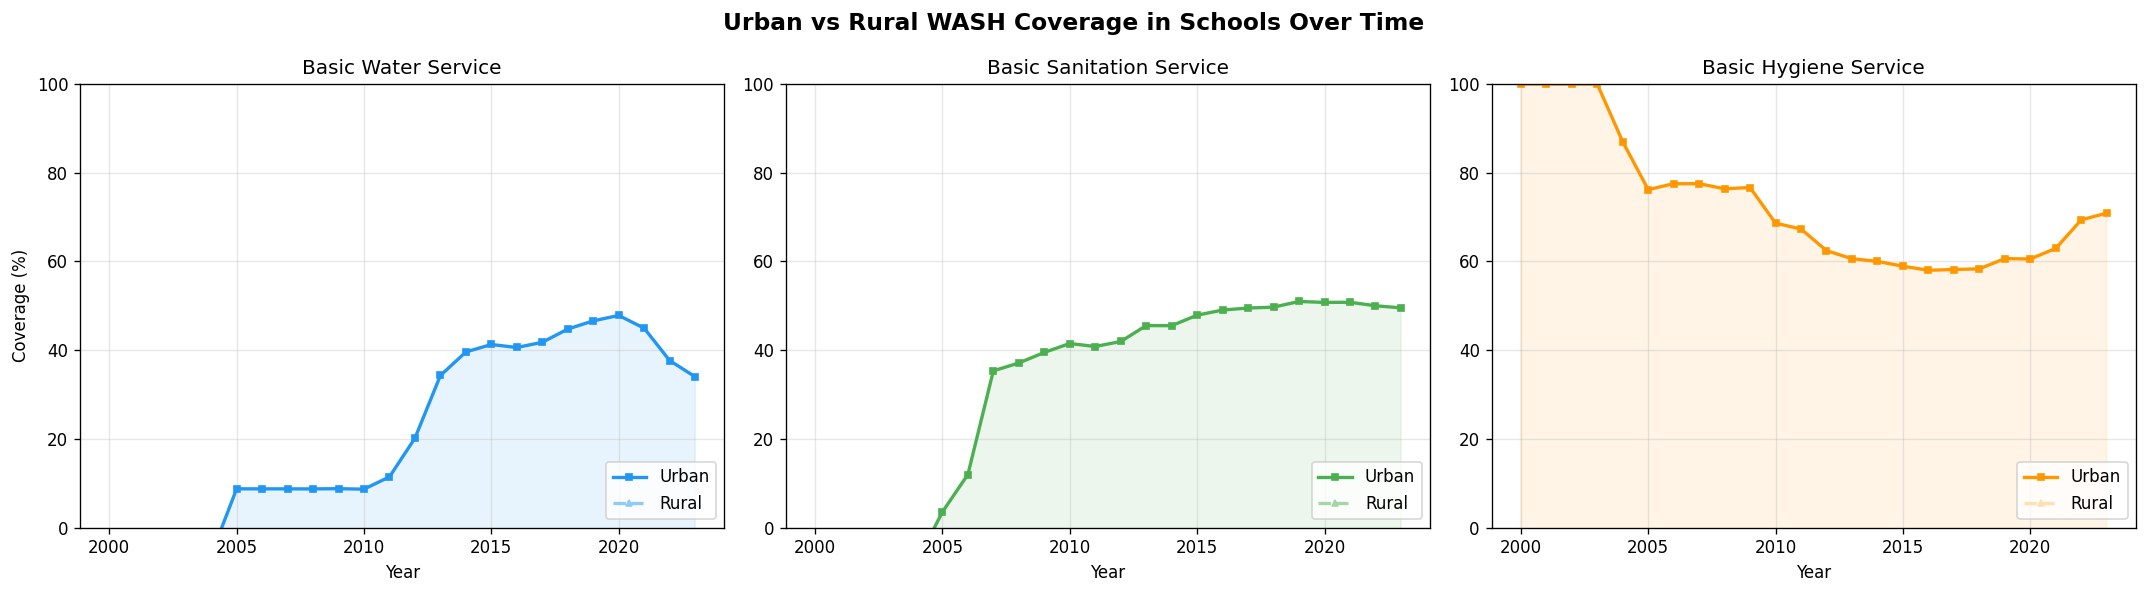

In [5]:
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle('Urban vs Rural WASH Coverage in Schools Over Time', fontsize=14, fontweight='bold')

pairs = [
    (water, 'wat_bas_urb', 'wat_bas_rur', 'Water', '#2196F3', '#90CAF9'),
    (sanitation, 'san_bas_urb', 'san_bas_rur', 'Sanitation', '#4CAF50', '#A5D6A7'),
    (hygiene, 'hyg_bas_urb', 'hyg_bas_rur', 'Hygiene', '#FF9800', '#FFE0B2'),
]

for i, (sheet, urb_col, rur_col, title, c_urb, c_rur) in enumerate(pairs):
    urb = sheet.groupby('year')[urb_col].mean().dropna()
    rur = sheet.groupby('year')[rur_col].mean().dropna()
    axes3[i].plot(urb.index, urb.values, color=c_urb, linewidth=2, marker='s', markersize=4, label='Urban')
    axes3[i].plot(rur.index, rur.values, color=c_rur, linewidth=2, marker='^', markersize=4, label='Rural',
                  linestyle='--')
    axes3[i].fill_between(urb.index, rur.reindex(urb.index).values, urb.values, alpha=0.1, color=c_urb)
    axes3[i].set_title(f'Basic {title} Service')
    axes3[i].set_xlabel('Year')
    if i == 0:
        axes3[i].set_ylabel('Coverage (%)')
    axes3[i].set_ylim(0, 100)
    axes3[i].legend(loc='lower right')
    axes3[i].grid(alpha=0.3)

fig3.tight_layout()
plt.show()

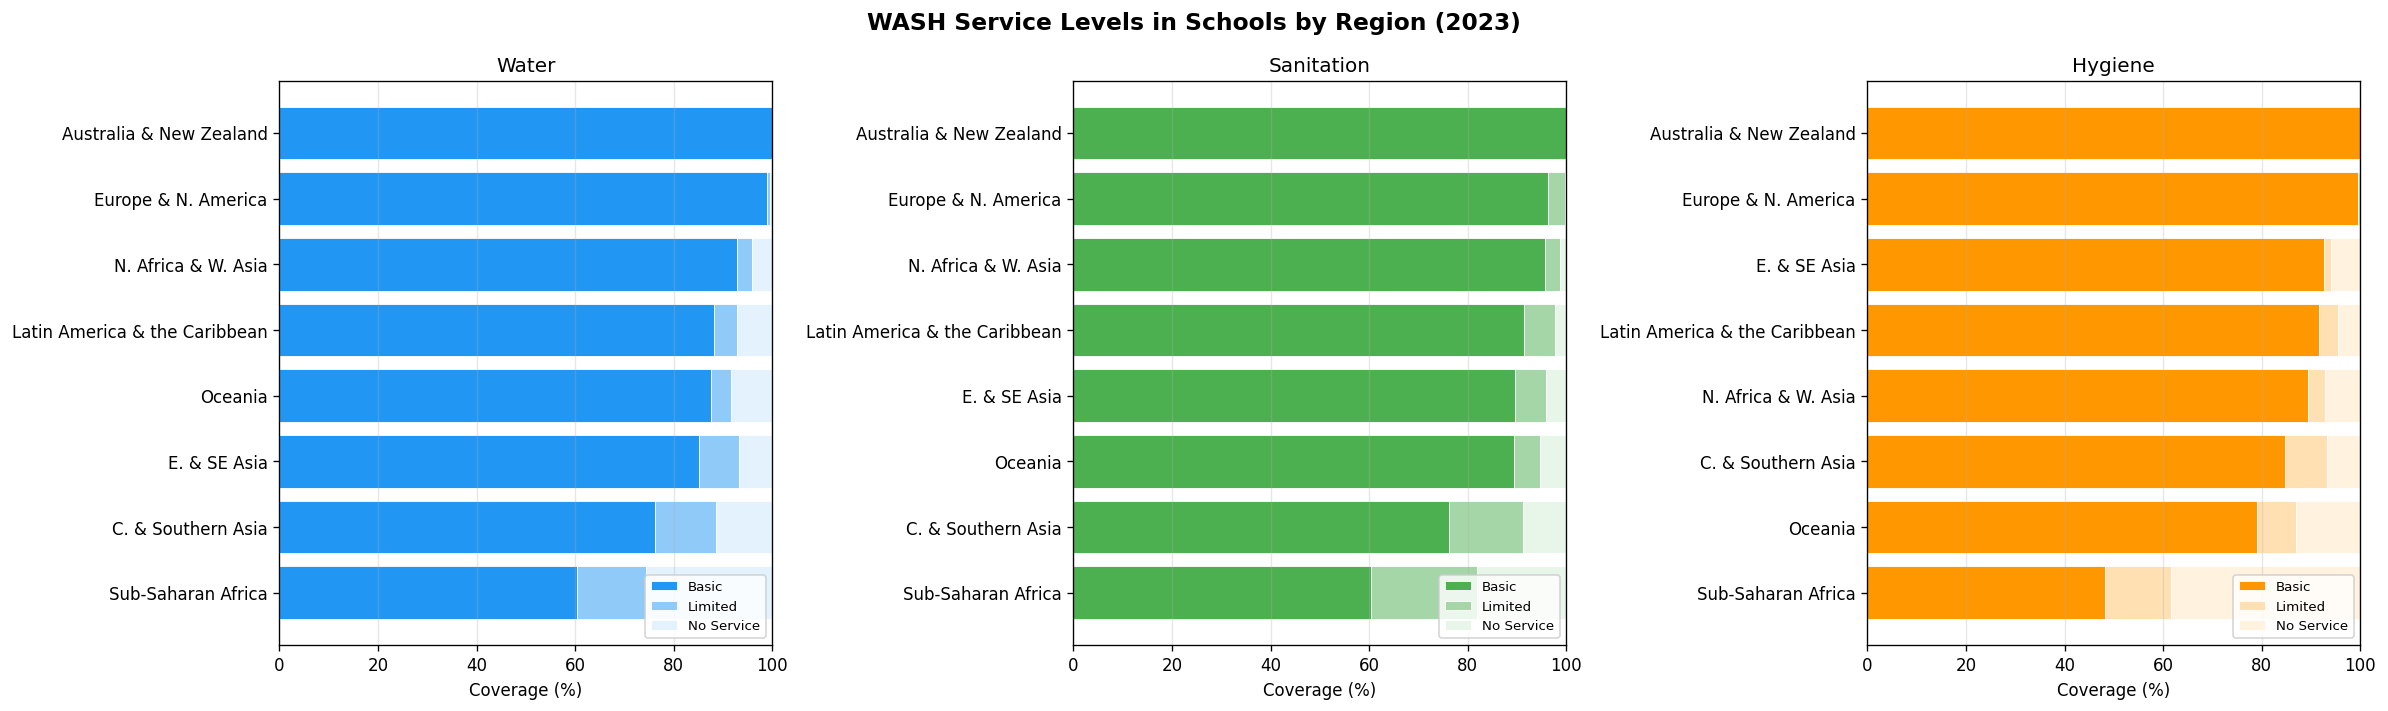

In [6]:
fig4, axes4 = plt.subplots(1, 3, figsize=(20, 6))
fig4.suptitle(f'WASH Service Levels in Schools by Region ({latest_year})', fontsize=14, fontweight='bold')

ladder_configs = [
    (water, ['wat_bas_nat', 'wat_lim_nat', 'wat_none_nat'],
     ['Basic', 'Limited', 'No Service'], ['#2196F3', '#90CAF9', '#E3F2FD'], 'Water'),
    (sanitation, ['san_bas_nat', 'san_lim_nat', 'san_none_nat'],
     ['Basic', 'Limited', 'No Service'], ['#4CAF50', '#A5D6A7', '#E8F5E9'], 'Sanitation'),
    (hygiene, ['hyg_bas_nat', 'hyg_lim_nat', 'hyg_none_nat'],
     ['Basic', 'Limited', 'No Service'], ['#FF9800', '#FFE0B2', '#FFF3E0'], 'Hygiene'),
]

for i, (sheet, cols, labels, colors, title) in enumerate(ladder_configs):
    latest = sheet[sheet['year'] == latest_year].dropna(subset=cols + ['region_sdg'])
    grouped = latest.groupby('region_sdg')[cols].mean()
    
    grouped.index = grouped.index.str.replace('and ', '& ', regex=False)
    grouped.index = grouped.index.str.replace('Northern ', 'N. ', regex=False)
    grouped.index = grouped.index.str.replace('South-Eastern ', 'SE ', regex=False)
    grouped.index = grouped.index.str.replace('Eastern ', 'E. ', regex=False)
    grouped.index = grouped.index.str.replace('Western ', 'W. ', regex=False)
    grouped.index = grouped.index.str.replace('Central ', 'C. ', regex=False)
    grouped = grouped.sort_values(cols[0])

    left = np.zeros(len(grouped))
    for j, (col, label, color) in enumerate(zip(cols, labels, colors)):
        axes4[i].barh(grouped.index, grouped[col], left=left, label=label,
                      color=color, edgecolor='white', linewidth=0.5)
        left += grouped[col].values

    axes4[i].set_xlim(0, 100)
    axes4[i].set_title(title)
    axes4[i].set_xlabel('Coverage (%)')
    axes4[i].legend(loc='lower right', fontsize=8)
    axes4[i].grid(axis='x', alpha=0.3)

fig4.tight_layout()
plt.show()

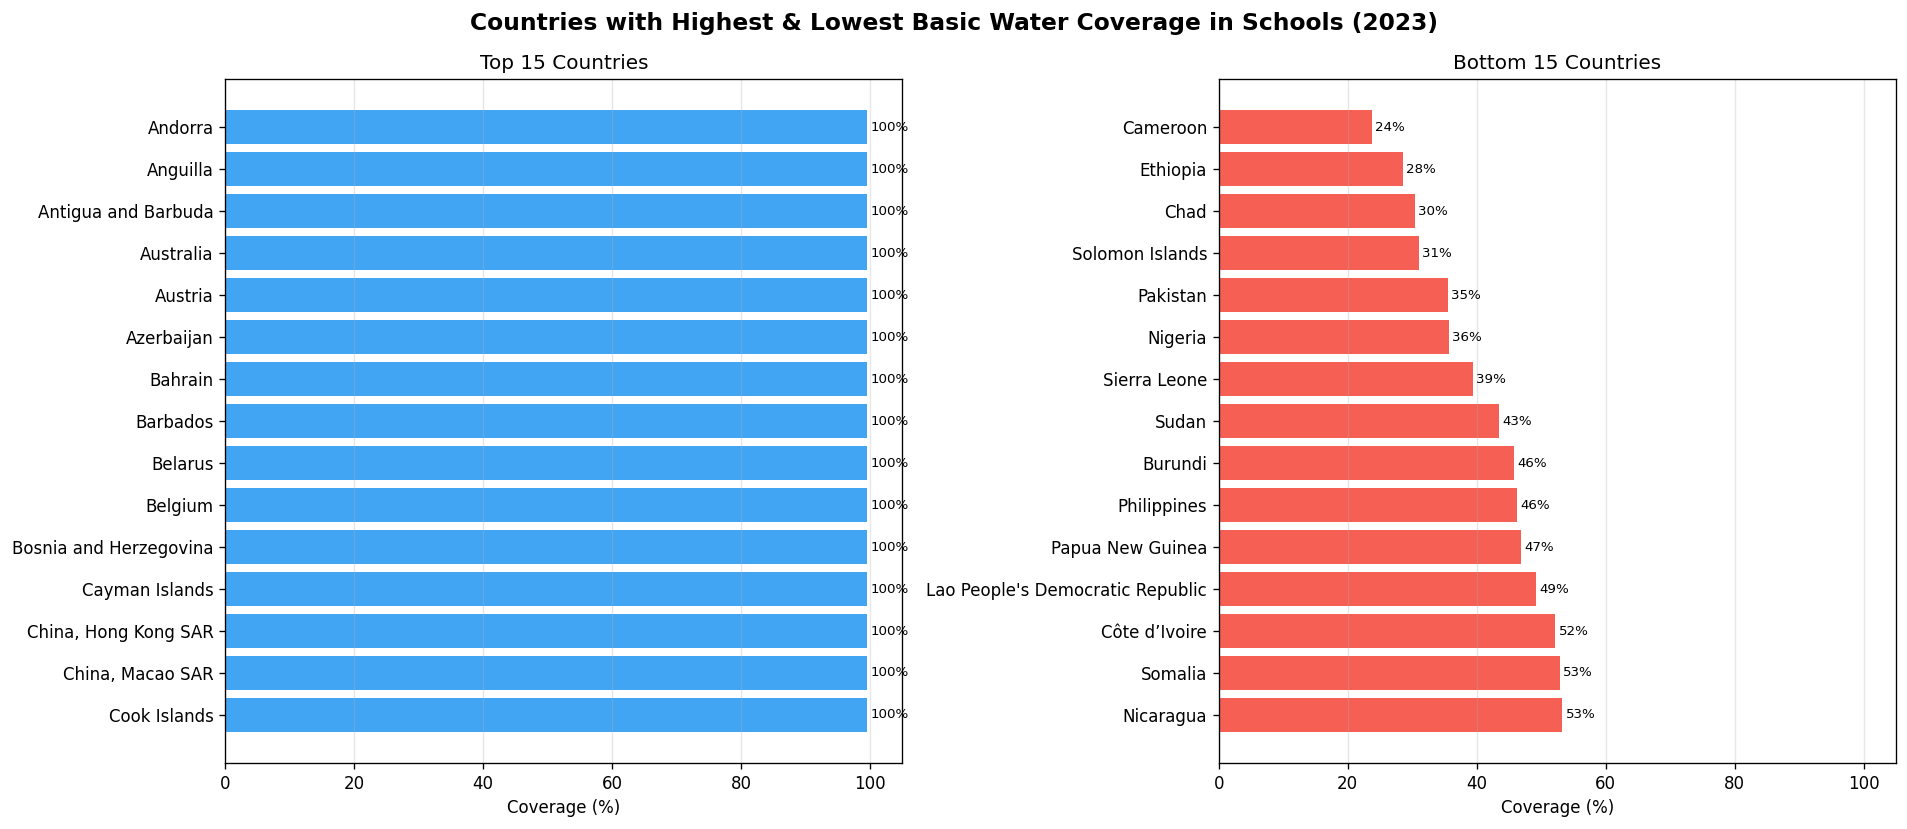

In [7]:
# Use cleaned data for top/bottom countries (excludes flagged sparse rows)
clean = df[df['all_basic_missing'] == False].copy()

fig5, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(16, 7))
fig5.suptitle('Countries with Highest & Lowest Basic Water Coverage in Schools (2023)',
              fontsize=14, fontweight='bold')

w_data = clean.dropna(subset=['wat_bas_nat'])
top15 = w_data.nlargest(15, 'wat_bas_nat')
bot15 = w_data.nsmallest(15, 'wat_bas_nat')

ax_top.barh(top15['country'], top15['wat_bas_nat'], color='#2196F3', alpha=0.85)
ax_top.set_xlim(0, 105)
ax_top.set_title('Top 15 Countries')
ax_top.set_xlabel('Coverage (%)')
ax_top.invert_yaxis()
ax_top.grid(axis='x', alpha=0.3)
for bar, val in zip(ax_top.patches, top15['wat_bas_nat']):
    ax_top.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
                va='center', fontsize=8)

ax_bot.barh(bot15['country'], bot15['wat_bas_nat'], color='#F44336', alpha=0.85)
ax_bot.set_xlim(0, 105)
ax_bot.set_title('Bottom 15 Countries')
ax_bot.set_xlabel('Coverage (%)')
ax_bot.invert_yaxis()
ax_bot.grid(axis='x', alpha=0.3)
for bar, val in zip(ax_bot.patches, bot15['wat_bas_nat']):
    ax_bot.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
                va='center', fontsize=8)

fig5.tight_layout()
plt.show()

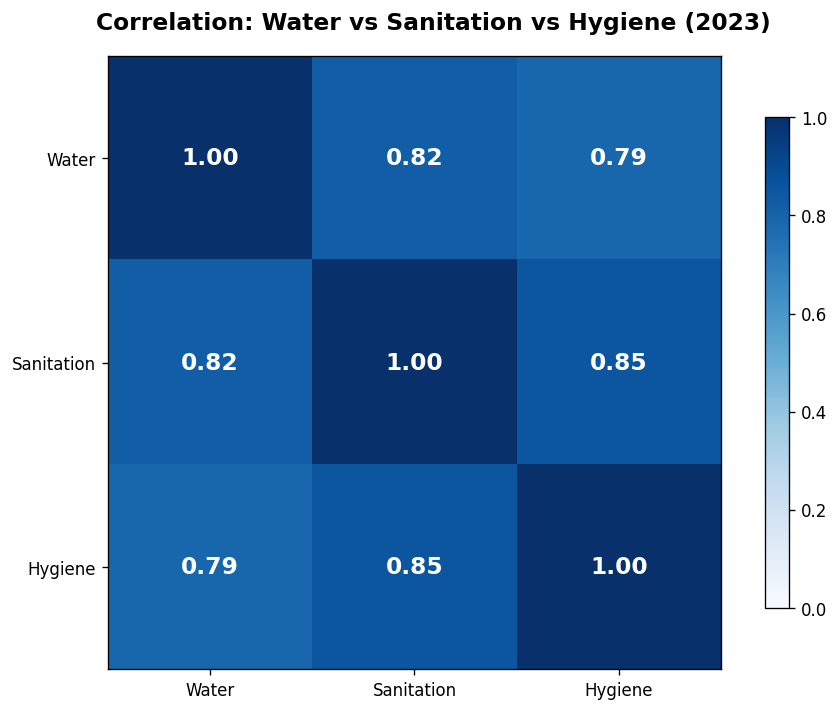

In [8]:
# Use cleaned data for correlation heatmap
clean = df[df['all_basic_missing'] == False].copy()

fig6, ax6 = plt.subplots(figsize=(8, 6))
fig6.suptitle('Correlation: Water vs Sanitation vs Hygiene (2023)', fontsize=14, fontweight='bold')

corr_data = clean[['wat_bas_nat', 'san_bas_nat', 'hyg_bas_nat']].dropna()
corr_data.columns = ['Water', 'Sanitation', 'Hygiene']
corr = corr_data.corr()

im = ax6.imshow(corr, cmap='Blues', vmin=0, vmax=1)
ax6.set_xticks([0, 1, 2])
ax6.set_yticks([0, 1, 2])
ax6.set_xticklabels(['Water', 'Sanitation', 'Hygiene'])
ax6.set_yticklabels(['Water', 'Sanitation', 'Hygiene'])
for i_r in range(3):
    for j_c in range(3):
        ax6.text(j_c, i_r, f'{corr.iloc[i_r, j_c]:.2f}', ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if corr.iloc[i_r, j_c] > 0.6 else 'black')
fig6.colorbar(im, ax=ax6, shrink=0.8)
fig6.tight_layout()
plt.show()